In [7]:
# ============================================================
# CELDA 1 · Cargar datos procesados y configurar MLflow
# ============================================================

import numpy as np
import pandas as pd
import mlflow
import mlflow.sklearn
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score,
    recall_score, confusion_matrix, roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns

# ── Cargar los datos procesados del Día 3 ───────────────────
X_train = np.load('../data/processed/X_train.npy')
X_test  = np.load('../data/processed/X_test.npy')
y_train = np.load('../data/processed/y_train.npy')
y_test  = np.load('../data/processed/y_test.npy')

print(f"X_train: {X_train.shape}  →  {X_train.shape[0]} clientes, {X_train.shape[1]} features")
print(f"X_test:  {X_test.shape}   →  {X_test.shape[0]} clientes, {X_test.shape[1]} features")
print(f"\nDistribución y_train: {np.bincount(y_train.astype(int))}")
print(f"Distribución y_test:  {np.bincount(y_test.astype(int))}")

# ── Configurar MLflow ────────────────────────────────────────
# Crea una carpeta mlruns/ en el proyecto para guardar los experimentos
mlflow.set_tracking_uri('../mlruns')

# Nombre del experimento — agrupa todos los modelos bajo el mismo nombre
mlflow.set_experiment('churn_prediction')

print("\n✅ MLflow configurado correctamente")
print("Los experimentos se guardarán en ../mlruns/")

X_train: (5634, 46)  →  5634 clientes, 46 features
X_test:  (1409, 46)   →  1409 clientes, 46 features

Distribución y_train: [4139 1495]
Distribución y_test:  [1035  374]

✅ MLflow configurado correctamente
Los experimentos se guardarán en ../mlruns/


In [8]:
# ============================================================
# CELDA 2 · Función reutilizable de entrenamiento + MLflow
# ============================================================

def entrenar_y_registrar(nombre, modelo, X_train, X_test, y_train, y_test):
    # Recibe el nombre del modelo, el modelo en sí, y los cuatro conjuntos de datos.
    """
    Entrena un modelo, evalúa con cross-validation y test,
    registra todo en MLflow y devuelve las métricas.
    """
    
    with mlflow.start_run(run_name=nombre):
        # El with abre un "run" de MLflow — un contenedor que agrupa todo lo que ocurra 
        # dentro: parámetros, métricas y el modelo. Cuando el bloque with termina, MLflow cierra el run automáticamente y lo guarda en disco.
        
        # ── 1. Cross-validation (5 folds) ───────────────────
        # Divide X_train en 5 partes iguales
        # Entrena con 4 partes y evalúa con 1 → repite 5 veces
        # Devuelve 5 scores → tomamos la media
        # Stratified → mantiene proporción 73/27 en cada fold
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        
        cv_scores = cross_val_score(
            modelo, X_train, y_train,
            cv=cv, scoring='roc_auc', n_jobs=-1 # Esto usa todos los núcleos del procesador 
        )                                       # para ejecutar los 5 folds en paralelo, por eso es más rápido que hacerlo manualmente.    
        
        cv_mean = cv_scores.mean()
        cv_std  = cv_scores.std()
        
        print(f"\n{'='*50}")
        print(f"Modelo: {nombre}")
        print(f"Cross-validation ROC-AUC: {cv_mean:.4f} (+/- {cv_std:.4f})")
        
        # ── 2. Entrenar con todos los datos de train ─────────
        # La cross-validation era solo para medir la estabilidad del modelo. 
        # El modelo que guardamos al final usa el 100% de los datos de entrenamiento.
        modelo.fit(X_train, y_train)
        
        # ── 3. Evaluar con datos de test ──────────────────────
        y_pred       = modelo.predict(X_test)
        y_pred_proba = modelo.predict_proba(X_test)[:, 1]
        
        roc_auc   = roc_auc_score(y_test, y_pred_proba)
        f1        = f1_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall    = recall_score(y_test, y_pred)
        
        print(f"Test ROC-AUC:  {roc_auc:.4f}")
        print(f"Test F1:       {f1:.4f}")
        print(f"Test Precision:{precision:.4f}")
        print(f"Test Recall:   {recall:.4f}")
        
        # ── 4. Registrar en MLflow ────────────────────────────
        # Parámetros del modelo
        mlflow.log_params(modelo.get_params())
        
        # Métricas
        mlflow.log_metric('cv_roc_auc_mean', cv_mean)
        mlflow.log_metric('cv_roc_auc_std',  cv_std)
        mlflow.log_metric('test_roc_auc',    roc_auc)
        mlflow.log_metric('test_f1',         f1)
        mlflow.log_metric('test_precision',  precision)
        mlflow.log_metric('test_recall',     recall)
        
        # Modelo completo
        mlflow.sklearn.log_model(modelo, nombre)
        
        return {
            'nombre':    nombre,
            'modelo':    modelo,
            'roc_auc':   roc_auc,
            'f1':        f1,
            'precision': precision,
            'recall':    recall,
            'cv_mean':   cv_mean
        }

print("✅ Función de entrenamiento definida")

✅ Función de entrenamiento definida


In [9]:
# ============================================================
# CELDA 3 · Entrenar los 3 modelos
# ============================================================

# ── Calcular el peso para el desbalanceo ─────────────────────
# scale_pos_weight le dice a XGBoost que los casos positivos (churn)
# pesan más que los negativos → compensa el desbalanceo 73/27
n_neg = np.sum(y_train == 0)   # clientes que no se fueron
n_pos = np.sum(y_train == 1)   # clientes que sí se fueron
scale_pos_weight = n_neg / n_pos

print(f"scale_pos_weight: {scale_pos_weight:.2f}")
print(f"(Por cada cliente que se va hay {scale_pos_weight:.1f} que no se van)\n")

resultados = []

# ── MODELO 1: Logistic Regression ────────────────────────────
# El más simple. Aprende una línea que separa los dos grupos.
# Sirve como baseline: si los modelos más complejos no lo superan,
# algo está mal.
lr = LogisticRegression(
    max_iter=1000,       # iteraciones máximas para converger
    class_weight='balanced',  # equivalente a scale_pos_weight
    random_state=42
)
resultados.append(
    entrenar_y_registrar('LogisticRegression', lr, X_train, X_test, y_train, y_test)
)

# ── MODELO 2: Random Forest ───────────────────────────────────
# Entrena 200 árboles de decisión independientes y hace votación.
# Más robusto que un árbol solo, menos propenso a overfitting.
rf = RandomForestClassifier(
    n_estimators=200,    # número de árboles
    max_depth=10,        # profundidad máxima de cada árbol
    class_weight='balanced',
    random_state=42,
    n_jobs=-1            # usa todos los núcleos del procesador
)
resultados.append(
    entrenar_y_registrar('RandomForest', rf, X_train, X_test, y_train, y_test)
)

# ── MODELO 3: XGBoost ─────────────────────────────────────────
# El modelo más potente de los tres para datos tabulares.
# Construye árboles de forma secuencial: cada árbol corrige
# los errores del anterior (boosting).
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,   # desbalanceo
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
resultados.append(
    entrenar_y_registrar('XGBoost', xgb, X_train, X_test, y_train, y_test)
)

scale_pos_weight: 2.77
(Por cada cliente que se va hay 2.8 que no se van)


Modelo: LogisticRegression
Cross-validation ROC-AUC: 0.8460 (+/- 0.0124)
Test ROC-AUC:  0.8415
Test F1:       0.6136
Test Precision:0.5043
Test Recall:   0.7834

Modelo: RandomForest
Cross-validation ROC-AUC: 0.8429 (+/- 0.0082)
Test ROC-AUC:  0.8400
Test F1:       0.6195
Test Precision:0.5471
Test Recall:   0.7139

Modelo: XGBoost
Cross-validation ROC-AUC: 0.8377 (+/- 0.0100)
Test ROC-AUC:  0.8272
Test F1:       0.6132
Test Precision:0.5258
Test Recall:   0.7353


LogisticRegression gana en ROC-AUC: el dataset tiene relaciones bastante lineales como se vio en el EDA, ya que las variables más importantes tienen efectos directos y predecibles sobre el churn. Los modelos más complejos como XGBoost buscan patrones no lineales que en este dataset no existen en suficiente cantidad. En este caso, además, el Recall de LogisticRegression es el más alto (el 78% de los clientes que realmente se van son detectados). Los scores de Cross-validation y Test son muy parecidos en los tres modelos, hay consistencia. Además, no tenemos overfitting que correspondería a un CV alto y un Test bajo.

In [10]:
# ============================================================
# CELDA 4 · Comparar modelos y guardar el ganador
# ============================================================

# ── Tabla comparativa ─────────────────────────────────────────
print("\n=== COMPARATIVA FINAL DE MODELOS ===\n")
print(f"{'Modelo':<22} {'ROC-AUC':>8} {'F1':>8} {'Precision':>10} {'Recall':>8} {'CV-AUC':>8}")
print("-" * 70)
for r in resultados:
    print(f"{r['nombre']:<22} {r['roc_auc']:>8.4f} {r['f1']:>8.4f} "
          f"{r['precision']:>10.4f} {r['recall']:>8.4f} {r['cv_mean']:>8.4f}")

# ── Elegir el mejor por ROC-AUC ───────────────────────────────
mejor = max(resultados, key=lambda x: x['roc_auc'])
print(f"\n🏆 Mejor modelo: {mejor['nombre']} con ROC-AUC = {mejor['roc_auc']:.4f}")

# ── Guardar el mejor modelo ───────────────────────────────────
os.makedirs('../models', exist_ok=True)
joblib.dump(mejor['modelo'], '../models/best_model.pkl')
print(f"✅ Mejor modelo guardado en models/best_model.pkl")


=== COMPARATIVA FINAL DE MODELOS ===

Modelo                  ROC-AUC       F1  Precision   Recall   CV-AUC
----------------------------------------------------------------------
LogisticRegression       0.8415   0.6136     0.5043   0.7834   0.8460
RandomForest             0.8400   0.6195     0.5471   0.7139   0.8429
XGBoost                  0.8272   0.6132     0.5258   0.7353   0.8377

🏆 Mejor modelo: LogisticRegression con ROC-AUC = 0.8415
✅ Mejor modelo guardado en models/best_model.pkl



=== INTERPRETACIÓN DE LA MATRIZ DE CONFUSIÓN ===
Verdaderos Negativos (TN): 747  → predijo No Churn y era correcto
Falsos Positivos     (FP): 288  → predijo Churn pero no se fue
Falsos Negativos     (FN): 81  → predijo No Churn pero sí se fue ⚠️
Verdaderos Positivos (TP): 293  → predijo Churn y era correcto

⚠️ Los Falsos Negativos son el error más costoso:
   Son clientes que SÍ se fueron y el modelo no detectó


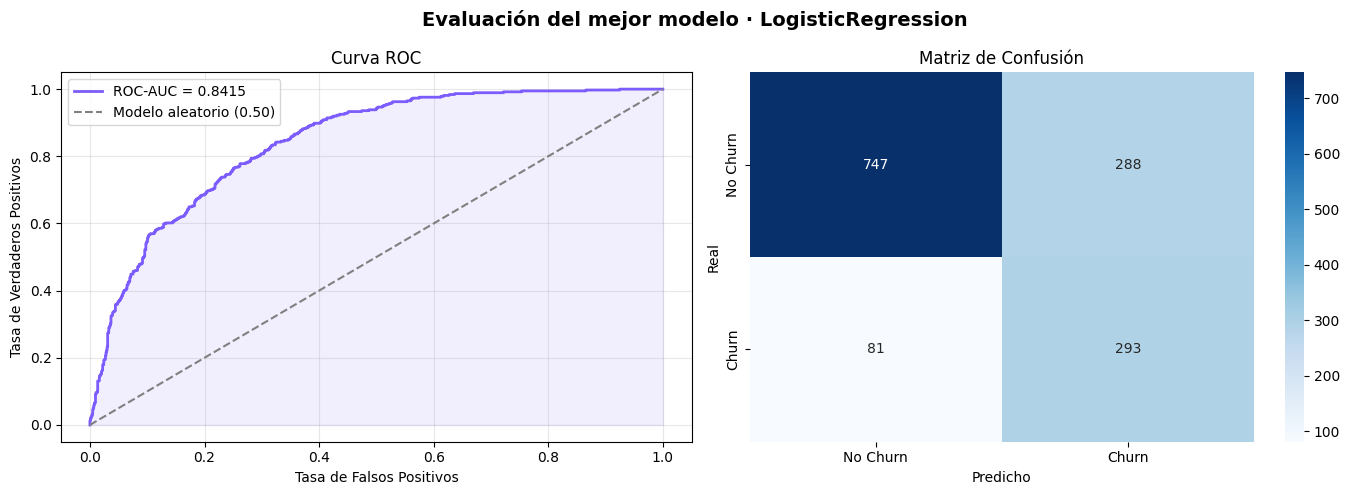


✅ Gráfica guardada en reports/figures/model_evaluation.png


In [11]:
# ============================================================
# CELDA 5 · Visualizaciones del mejor modelo
# ============================================================

modelo_ganador = mejor['modelo']
y_pred         = modelo_ganador.predict(X_test)
y_pred_proba   = modelo_ganador.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Evaluación del mejor modelo · {mejor["nombre"]}',
             fontsize=14, fontweight='bold')

# ── Gráfica 1: Curva ROC ──────────────────────────────────────
# Muestra el tradeoff entre detectar churn real (TPR)
# y generar falsas alarmas (FPR) a distintos umbrales
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[0].plot(fpr, tpr, color='#7c5cfc', lw=2,
             label=f'ROC-AUC = {mejor["roc_auc"]:.4f}')
axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--',
             label='Modelo aleatorio (0.50)')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='#7c5cfc')
axes[0].set_xlabel('Tasa de Falsos Positivos')
axes[0].set_ylabel('Tasa de Verdaderos Positivos')
axes[0].set_title('Curva ROC')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── Gráfica 2: Matriz de confusión ───────────────────────────
# Muestra exactamente cuántos clientes clasificó bien y mal
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
axes[1].set_ylabel('Real')
axes[1].set_xlabel('Predicho')
axes[1].set_title('Matriz de Confusión')

# Añadir interpretación debajo de la matriz
tn, fp, fn, tp = cm.ravel()
print(f"\n=== INTERPRETACIÓN DE LA MATRIZ DE CONFUSIÓN ===")
print(f"Verdaderos Negativos (TN): {tn}  → predijo No Churn y era correcto")
print(f"Falsos Positivos     (FP): {fp}  → predijo Churn pero no se fue")
print(f"Falsos Negativos     (FN): {fn}  → predijo No Churn pero sí se fue ⚠️")
print(f"Verdaderos Positivos (TP): {tp}  → predijo Churn y era correcto")
print(f"\n⚠️ Los Falsos Negativos son el error más costoso:")
print(f"   Son clientes que SÍ se fueron y el modelo no detectó")

plt.tight_layout()
os.makedirs('../reports/figures', exist_ok=True)
plt.savefig('../reports/figures/model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Gráfica guardada en reports/figures/model_evaluation.png")

De los 374 clientes que realmente se fueron, el modelo detectó 293 (78.3%) a tiempo para hacer una oferta de retención. Solo se escaparon 81.   
**Nota**: El ratio FP/TP es aproximadamente 1:1 (288 falsas alarmas vs 293 aciertos). Esto confirma la Precision baja de 0.50 que vimos antes — por cada cliente en riesgo real, el modelo alerta sobre otro que no lo está. En negocio esto es completamente aceptable si el coste de una oferta de retención es menor que el coste de perder al cliente.